In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [32]:
X, y = make_classification(
    n_samples=800,
    n_features=40,
    n_informative=5,
    n_redundant=20,
    random_state=42
)

X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
model1 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(40,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

h1 = model1.fit(X_train, y_train,
                validation_split=0.2,
                epochs=50,
                verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model2 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(40,)),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

h2 = model2.fit(X_train, y_train,
                validation_split=0.2,
                epochs=50,
                verbose=0)

In [35]:
model3 = keras.Sequential([
    layers.Dense(256, input_shape=(40,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

h3 = model3.fit(X_train, y_train,
                validation_split=0.2,
                epochs=50,
                verbose=0)

In [36]:
model4 = keras.Sequential([
    layers.Dense(256, input_shape=(40,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(1, activation='sigmoid')
])

model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

h4 = model4.fit(X_train, y_train,
                validation_split=0.2,
                epochs=50,
                verbose=0)

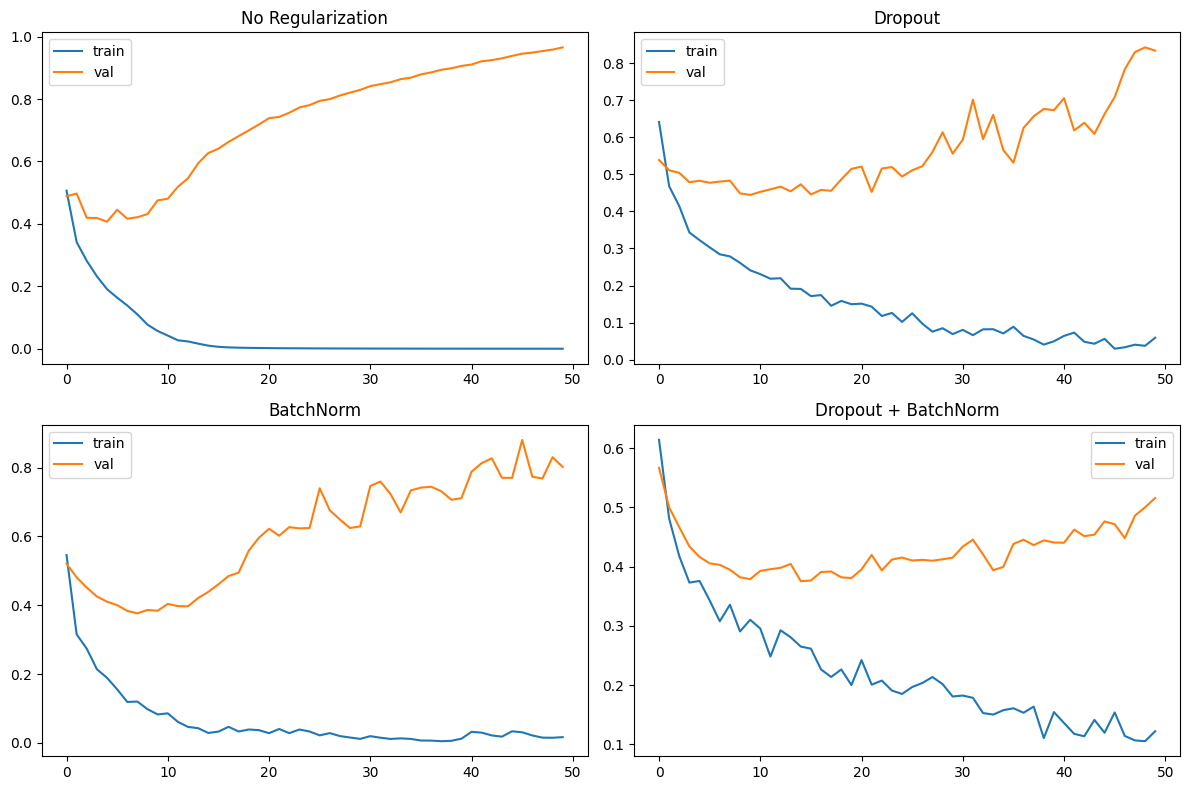

In [37]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

models = [h1, h2, h3, h4]
titles = ["No Regularization", "Dropout", "BatchNorm", "Dropout + BatchNorm"]

for i, h in enumerate(models):
    ax[i//2][i%2].plot(h.history['loss'], label='train')
    ax[i//2][i%2].plot(h.history['val_loss'], label='val')
    ax[i//2][i%2].set_title(titles[i])
    ax[i//2][i%2].legend()

plt.tight_layout()
plt.show()

In [38]:
models = [model1, model2, model3, model4]
names = ["No Reg", "Dropout", "BatchNorm", "Dropout+BN"]

results = []

for m, n in zip(models, names):
    pred = (m.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, pred)
    val_loss = min(m.history.history['val_loss']) if hasattr(m, "history") else None
    results.append([n, acc])

pd.DataFrame(results, columns=["Model", "Test Accuracy"])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 


,Model,Test Accuracy
0,No Reg,0.80000
1,Dropout,0.78750
2,BatchNorm,0.80625
3,Dropout+BN,0.80625


In [39]:
print("""
CONCLUSION:

1. No Regularization:
   High training accuracy
   Poor validation performance
   Strong overfitting observed

2. Dropout:
    Reduced overfitting
    Better generalization

3. Batch Normalization:
    Faster convergence
    Stable training
    Better than no regularization

4. Dropout + BatchNorm:
    Best overall performance
    Most stable validation curve
    Highest generalization

FINAL RESULT:
Combination of Dropout + Batch Normalization works best for this dataset.
""")


CONCLUSION:

1. No Regularization:
   High training accuracy
   Poor validation performance
   Strong overfitting observed

2. Dropout:
    Reduced overfitting
    Better generalization

3. Batch Normalization:
    Faster convergence
    Stable training
    Better than no regularization

4. Dropout + BatchNorm:
    Best overall performance
    Most stable validation curve
    Highest generalization

FINAL RESULT:
Combination of Dropout + Batch Normalization works best for this dataset.



In [40]:
model1.save("model_no_reg.keras")
model2.save("model_dropout.keras")
model3.save("model_batchnorm.keras")
model4.save("model_dropout_bn.keras")

In [41]:
from google.colab import files

files.download("model_no_reg.keras")
files.download("model_dropout.keras")
files.download("model_batchnorm.keras")
files.download("model_dropout_bn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>